In [17]:
import sys
import numpy as np
import pandas as pd
import scipy
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

from pyproj import CRS, Transformer
from scipy.spatial.distance import pdist, squareform

import pyvista as pv

from scipy.spatial.distance import pdist, squareform

print("Python:", sys.version)
print("NumPy:", np.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pd.__version__)

Python: 3.12.13 | packaged by conda-forge | (main, Aug 11 2026, 10:27:28) [GCC 14.4.0]
NumPy: 2.5.2
SciPy: 1.18.0
Pandas: 3.0.5


### Lets start with loading the data

In [2]:
#Defining path to file
path = "/mnt/c/Users/josem/OneDrive/Documents/Dummy_data/new_dummy_data2.csv" # r'/path' for windows

# using pandas pd.read_csv(path) I will load in the data
df = pd.read_csv(path)

### Now we will visualize the data in 3D

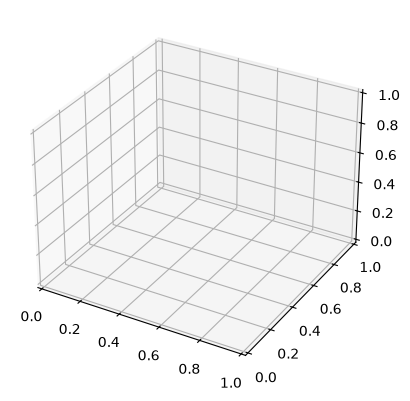

In [3]:
# Using matplotlib for now
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt

# defining figure and axis
fig = plt.figure()
ax = plt.axes(projection='3d')


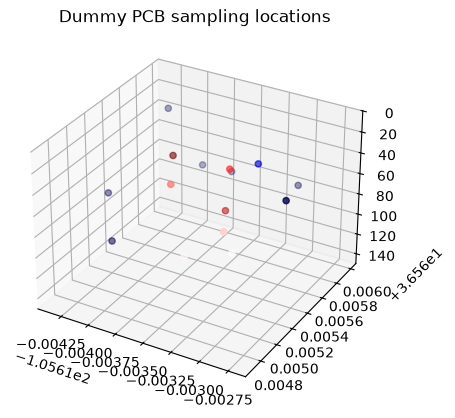

In [4]:
# assigning x,y,z to frame
fig = plt.figure()
ax = plt.axes(projection='3d')

x=df['long']
y=df['lat']
z=df['depth']
c=df['PCB']

ax.scatter(x, y, z,c=c, cmap='seismic')

ax.set_zlim(0,150)
ax.invert_zaxis()  # This flips the z-axis direction

ax.set_title('Dummy PCB sampling locations')

plt.show()

### Doing some prelimenary statistical stuff

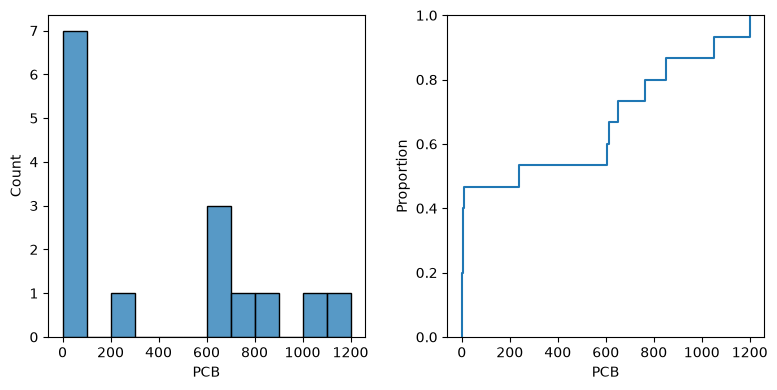

In [5]:
import seaborn as sns

contaminant = "PCB"

fig, axes = plt.subplots(1,2, figsize=(8, 4))

sns.histplot(
    data=df,
    x=contaminant,
    binwidth=100,
    ax=axes[0],
)

sns.ecdfplot(
    data=df,
    x=contaminant,
    ax=axes[1],
)

fig.tight_layout()
plt.show()

In [6]:
print(f"The minimum {contaminant} value  is: {df[contaminant].min():.2f}")
print(f"The maximum {contaminant} value  is: {df[contaminant].max():.2f}")
print(f"The median {contaminant}  value  is: {df[contaminant].median():.2f}")
print(f"The average {contaminant} value  is: {df[contaminant].mean():.2f}")
print(f"The standard deviation is: {df[contaminant].std():.2f}")

The minimum PCB value  is: 0.00
The maximum PCB value  is: 1200.00
The median PCB  value  is: 240.00
The average PCB value  is: 400.00
The standard deviation is: 437.02


Now log -transforming the data

In [7]:
df_log = df.copy()
df_log["PCB_log1p"] = np.log1p(df_log["PCB"])


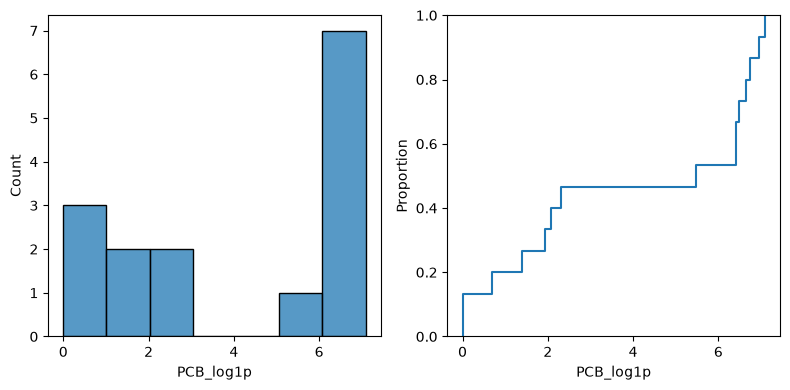

In [8]:
contaminant_log = "PCB_log1p"
fig, axes = plt.subplots(1,2, figsize=(8, 4))

sns.histplot(
    data=df_log,
    x=contaminant_log,
    binwidth=1,
    ax=axes[0],
)

sns.ecdfplot(
    data=df_log,
    x=contaminant_log,
    ax=axes[1],
)

fig.tight_layout()
plt.show()

In [9]:
print(f"The minimum {contaminant_log} value  is: {df_log[contaminant_log].min():.2f}")
print(f"The maximum {contaminant_log} value  is: {df_log[contaminant_log].max():.2f}")
print(f"The median {contaminant_log}  value  is: {df_log[contaminant_log].median():.2f}")
print(f"The average {contaminant_log} value  is: {df_log[contaminant_log].mean():.2f}")
print(f"The standard deviation is: {df_log[contaminant_log].std():.2f}")

The minimum PCB_log1p value  is: 0.00
The maximum PCB_log1p value  is: 7.09
The median PCB_log1p  value  is: 5.48
The average PCB_log1p value  is: 4.04
The standard deviation is: 2.85


### Determine the CRS and project the monitoring-well coordinates

Monitoring-well locations are often recorded as longitude and latitude. These are angular coordinates measured in degrees, not linear distances measured in feet or meters.

This becomes a serious problem for 3D modeling when the vertical coordinate—such as elevation, depth, or screened-interval elevation—is measured in meters or feet. If we interpolate directly using longitude, latitude, and elevation, the three coordinate axes have incompatible units:

$$
(\text{longitude in degrees},\ \text{latitude in degrees},\ \text{elevation in meters})
$$

A numerical interpolator generally treats these values as coordinates in one common distance system. It does not understand that one axis contains degrees while another contains meters.

One degree of latitude is approximately 111 kilometers. The distance represented by one degree of longitude varies with latitude and is approximately

$$
111\cos(\phi)\ \text{kilometers},
$$

where \(\phi\) is latitude. At approximately \(36.56^\circ\text{N}\), one degree of longitude represents about 89 kilometers.

Consequently, a seemingly small horizontal coordinate difference such as \(0.001^\circ\) may represent roughly 90–110 meters. Comparing that numerical difference directly with a vertical difference of 10 meters would badly distort the geometry used by the interpolator.

Before calculating distances or performing interpolation, we should therefore:

1. Identify the coordinate reference system (CRS) of the input data.
2. Transform longitude and latitude into an appropriate projected CRS.
3. Verify that the projected horizontal units are meters.
4. Convert vertical measurements into the same linear unit.
5. Document the meaning and vertical datum of the elevation values.

For this synthetic dataset, we assume that the input coordinates use WGS 84:

```python
source_crs = "EPSG:4326"
```

The wells are located near longitude $-105.61^\circ$ and latitude $36.56^\circ$ N. Therefore, UTM Zone 13N is an appropriate projected CRS for this local experiment:

```python
model_crs = "EPSG:32613"
```

After transformation, the modeling coordinates will have the form:

$$
(X\text{ in meters},\ Y\text{ in meters},\ Z\text{ in meters})
$$

This gives the numerical model a consistent geometric foundation. It does not yet determine how strongly vertical and horizontal separation should influence concentration. That requires an explicit hydrogeologic anisotropy model later. However, projection removes the fundamental error of mixing angular coordinates in degrees with vertical coordinates in linear units.

In [10]:
def validate_projection(
    df_,
    X1,
    Y1,
    source_crs,
    model_crs,
):
    """Verify projected X/Y by transforming them back to source coordinates."""

    reverse_transformer = Transformer.from_crs(
        model_crs,
        source_crs,
        always_xy=True,
    )

    X_test, Y_test = reverse_transformer.transform(
        df_["X"].to_numpy(),
        df_["Y"].to_numpy(),
    )

    coordinates_match = (
        np.allclose(
            X_test,
            df_[X1].to_numpy(),
            atol=1e-8,
        )
        and np.allclose(
            Y_test,
            df_[Y1].to_numpy(),
            atol=1e-8,
        )
    )

    if not coordinates_match:
        raise ValueError(
            "Projected coordinates failed the round-trip check."
        )

    return True

def project_coordinates(
    df,
    Longitude,
    Latitude,
    source_crs,
    model_crs,
):
    if Longitude not in df.columns:
        raise ValueError(f"Missing longitude column: {Longitude}")

    if Latitude not in df.columns:
        raise ValueError(f"Missing latitude column: {Latitude}")
        
    projected_df = df.copy()

    transformer = Transformer.from_crs(
        source_crs,
        model_crs,
        always_xy = True
    )

    projected_df['X'], projected_df['Y'] = transformer.transform(
        projected_df[Longitude].to_numpy(),
        projected_df[Latitude].to_numpy(),    
    )
# checking if projection transformation worked out
    validate_projection(
    projected_df,
    X1=Longitude,
    Y1=Latitude,
    source_crs=source_crs,
    model_crs=model_crs,
    )
    
    return projected_df
    


In [11]:
source_crs = "EPSG:4326"
model_crs = "EPSG:32613"
Longitude = 'long'
Latitude = 'lat'

df = project_coordinates(df,Longitude,Latitude,source_crs,model_crs)

In [12]:
### use function above. this was to help create function

from pyproj import CRS, Transformer
from scipy.spatial.distance import pdist, squareform

# defining strings in case different spreadsheets have different
# variable names
Longitude = 'long'
Latitude = 'lat'

# Define the source and modeling coordinate systems.
source_crs = CRS.from_epsg(4326)   # WGS 84 longitude/latitude
model_crs = CRS.from_epsg(32613)  # WGS 84 / UTM Zone 13N

# Building the coordinate transformer
transformer = Transformer.from_crs(
    source_crs,
    model_crs,
    always_xy = True,
)

# Creating X and Y variables that will have new projected coordinates
df['X'], df['Y'] = transformer.transform(
    df[Longitude].to_numpy(),
    df[Latitude].to_numpy()
)
# doing the same for log transformed data set we created. Just in case!
df_log['X'], df['Y'] = transformer.transform(
    df[Longitude].to_numpy(),
    df[Latitude].to_numpy()
)

### Interactive 3D visualization with PyVista

Matplotlib is useful for static plots and diagnostics, but PyVista allows us to rotate, zoom, and inspect spatial data interactively. PyVista is built on the Visualization Toolkit (VTK), a widely used scientific visualization library.

Each monitoring-well sample has three spatial coordinates:

$$
(X,\ Y,\ Z)
$$

The projected $(X)$ and $(Y)$ coordinates are measured in meters. The dataset records depth as a positive distance below the ground surface. For visualization, we define:

$$
Z=-\text{depth}
$$

This places deeper samples lower on the vertical axis. It establishes the ground surface as a temporary local reference where $(Z=0)$.


PyVista will later support several OpenPlumes tasks:

- interactive inspection of monitoring-well geometry;
- visualization of three-dimensional prediction grids;
- display of concentration slices and contours;
- comparison of interpolation results;
- visualization of plume isosurfaces;
- inspection of triangle orientation and mesh quality;
- export of scientific meshes.

At this stage, PyVista is being used to inspect the input sample geometry. No interpolation or plume surface has been created yet.

In [13]:
def create_well_points(df,X ,Y ,Z):
    X, Y, Z = df['X'],df['Y'],df['depth']

    well_points = np.column_stack(
        (
            X.to_numpy(),
            Y.to_numpy(),
            -Z.to_numpy(),
        )
    )
    return well_points

well_points = create_well_points(
    df,
    X='X',
    Y='Y',
    Z='depth',
)

In [14]:
pdata = pv.PolyData(well_points)
contaminants = ["PCB"]

def add_contaminants(wells, df_, list_of_contaminants):
    if len(df_) != wells.n_points:
        raise ValueError(
            "The number of DataFrame rows does not match "
            "the number of PyVista points."
        )
    for contaminant in list_of_contaminants:
        if contaminant not in df_.columns:
            raise ValueError(
                f"Contaminant '{contaminant}' is not in the original data."
            )
        wells[contaminant] = df_[contaminant].to_numpy()
    return wells


In [15]:
pdata = add_contaminants(
    wells=pdata,
    df_=df,
    list_of_contaminants=contaminants,
)

In [16]:
# create many spheres from the point cloud
sphere = pv.Sphere(radius=2, phi_resolution=10, theta_resolution=10)
pc = pdata.glyph(scale=False, geom=sphere, orient=False)
pc.plot(cmap='seismic')

Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/chema/miniforge3/envs/openplumes/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x793a4c23dc40> is already entered
Exception in callback Task.__step()
handle: <Handle Task.__step()>
Traceback (most recent call last):
  File "/home/chema/miniforge3/envs/openplumes/lib/python3.12/asyncio/events.py", line 88, in _run
    self._context.run(self._callback, *self._args)
RuntimeError: cannot enter context: <_contextvars.Context object at 0x793a4c23dc40> is already entered


Widget(value='<iframe src="http://localhost:46095/index.html?ui=P_0x79398c297f20_0&reconnect=auto" class="pyvi…

### Running some diagnostics before doing any interpolating

In [56]:
from scipy.spatial.distance import pdist, squareform

X, Y, Z = df['X'],df['Y'],df['depth']
def coordinate_diagnostics(X,Y,Z):
   
    # calculating minimum, maximum, and span for each coordinate
    diagnostics = {
    #"X_min": X.min(),
    #"X_max": X.max(),
    "X_span": X.max() - X.min(),
    #"Y_min": Y.min(),
    #"Y_max": Y.max(),
    "Y_span":Y.max() - Y.min(),
    "Z_min": Z.min(),
    "Z_max": Z.max(),
    "Z_span": Z.max() - Z.min()}
    diagnostics= {k: float(v) for k, v in diagnostics.items()}
    return diagnostics

coordinate_diagnostics(X,Y,Z)

{'X_span': 145.86965996830259,
 'Y_span': 141.56267887167633,
 'Z_min': 30.0,
 'Z_max': 100.0,
 'Z_span': 70.0}

In [75]:
### assuming all X,Y,Z are pulled from same place like above maybe think class takes df and diagnostics functions take x,y,z from df
def pairwise_horizontal_distances(df_, X, Y):
    """Return condensed and square horizontal-distance arrays."""

    coordinates = df_[[X, Y]].to_numpy(dtype=float)

    condensed_distance = pdist(
        coordinates,
        metric="euclidean",
    )

    distance_matrix = squareform(condensed_distance)

    return condensed_distance, distance_matrix

condensed_distance, distance_matrix = (
    pairwise_horizontal_distances(
        df,
        X="X",
        Y="Y",
    )
)

In [79]:
print(condensed_distance.shape)
print(distance_matrix.shape)
print(np.allclose(distance_matrix, distance_matrix.T))
print(np.diag(distance_matrix))

(105,)
(15, 15)
True
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Making heatmaps of the pairwise diagnostics

In [80]:
distance_df = pd.DataFrame(
    distance_matrix,
    index=df["Well_ID"],
    columns=df["Well_ID"],
)

<Axes: xlabel='Well_ID', ylabel='Well_ID'>

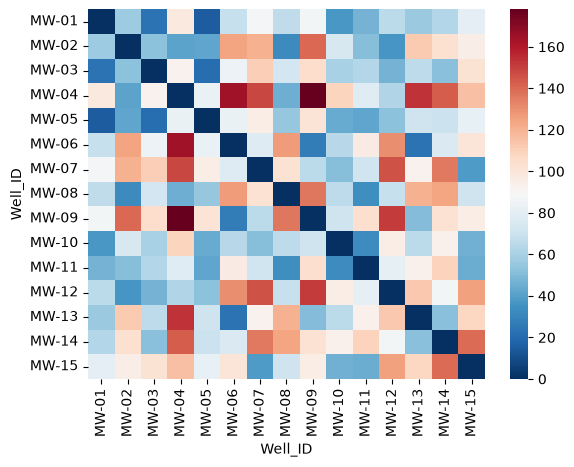

In [86]:
sns.heatmap(distance_df,cmap='RdBu_r')

In [87]:
well_ids = df["Well_ID"].to_numpy()

# Ignore self-distances when searching for the closest pair.
distance_without_diagonal = distance_matrix.copy()
np.fill_diagonal(distance_without_diagonal, np.inf)

closest_indices = np.unravel_index(
    np.argmin(distance_without_diagonal),
    distance_matrix.shape,
)

farthest_indices = np.unravel_index(
    np.argmax(distance_matrix),
    distance_matrix.shape,
)

print(
    "Closest pair:",
    well_ids[closest_indices[0]],
    well_ids[closest_indices[1]],
    f"{distance_matrix[closest_indices]:.2f} m",
)

print(
    "Farthest pair:",
    well_ids[farthest_indices[0]],
    well_ids[farthest_indices[1]],
    f"{distance_matrix[farthest_indices]:.2f} m",
)

Closest pair: MW-01 MW-05 15.02 m
Farthest pair: MW-04 MW-09 178.02 m


In [88]:
nearest_indices = np.argmin(
    distance_without_diagonal,
    axis=1,
)

nearest_distances = distance_without_diagonal[
    np.arange(len(df)),
    nearest_indices,
]

nearest_neighbor_df = pd.DataFrame(
    {
        "Well_ID": well_ids,
        "Nearest_Well": well_ids[nearest_indices],
        "Distance_m": nearest_distances,
    }
)

nearest_neighbor_df.sort_values("Distance_m")

,Well_ID,Nearest_Well,Distance_m
0,MW-01,MW-05,15.021746
4,MW-05,MW-01,15.021746
2,MW-03,MW-05,20.873347
5,MW-06,MW-13,23.586045
12,MW-13,MW-06,23.586045
8,MW-09,MW-06,26.780722
7,MW-08,MW-02,32.449657
1,MW-02,MW-08,32.449657
10,MW-11,MW-10,33.029884
9,MW-10,MW-11,33.029884


In [158]:
### use function above. this was to help create function

from pyproj import CRS, Transformer
from scipy.spatial.distance import pdist, squareform

# defining strings in case different spreadsheets have different
# variable names
Longitude = 'long'
Latitude = 'lat'

# Define the source and modeling coordinate systems.
source_crs = CRS.from_epsg(4326)   # WGS 84 longitude/latitude
model_crs = CRS.from_epsg(32613)  # WGS 84 / UTM Zone 13N

# Building the coordinate transformer
transformer = Transformer.from_crs(
    source_crs,
    model_crs,
    always_xy = True,
)

# Creating X and Y variables that will have new projected coordinates
df['X'], df['Y'] = transformer.transform(
    df[Longitude].to_numpy(),
    df[Latitude].to_numpy()
)
# doing the same for log transformed data set we created. Just in case!
df_log['X'], df['Y'] = transformer.transform(
    df[Longitude].to_numpy(),
    df[Latitude].to_numpy()
)